In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [42]:
files = os.listdir("Datasets")
xlsx_files = [os.path.join("Datasets", f) for f in files if f.endswith('.xlsx')]
df_list = [pd.read_excel(file) for file in xlsx_files]
df = pd.concat(df_list, ignore_index=True)
df.head()

,Campaña,Despacho,Cod. trans,Pedido,Zona,Código,Identificación,Nombres,Dirección entrega,Telefono,...,Longitud,Transportador,Track,Novedad,Entregado,Anotación,Transportista,Tipo Docu,Nro visita,Estado.1
0,202407,296461,23,37076500,V02,V02004028,29121278,PAOLA ANDREA RIVILLAS AMAYA,KR 61 18 16 APTO 486 TO V CONJ CANAVERALES 3- ...,0-3165249159,...,-76.501666,TZY274,ENTREGADO,NaN,TERCERO EN DOMICILIO,NaN,daissydiaz,F,1,A TIEMPO
1,202407,296601,23,37087842,601,601004287,26396193,CERBELINA MOSQUERA MOSQUERA,KR 47A 48 39- TEL 0-3143423923,0-3143423923,...,-76.501645,CBZ922,ENTREGADO,NaN,ASESORA,NaN,daissydiaz,F,1,A TIEMPO
2,202407,296601,23,37093297,580,580011140,1112490780,MANUELA RAMIREZ SANCHEZ,CR 1H NORTE 77-10 SEGUNDO PISO- TEL 0-3154678944,0-3154678944,...,-76.487991,TZY274,ENTREGADO,NaN,ASESORA,NaN,daissydiaz,F,1,A TIEMPO
3,202407,296621,23,37098642,594,594003236,66940803,FANERY CORRLES BERMUDES,CALLETERSERA SN124- TEL 0-3016931064,0-3016931064,...,-76.687145,TZN919,ENTREGADO,NaN,ASESORA,NaN,daissydiaz,F,1,A TIEMPO
4,202407,296832,23,37105003,603,60301124,25717466,MARCIA FLOREZ LOPEZ,CL 18 A 9 A 11 PISO NO 1- TEL 0-3136142043,0-3136142043,...,-76.531023,CEN356,ENTREGADO,NaN,ASESORA,NaN,daissydiaz,F,1,A TIEMPO


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55275 entries, 0 to 55274
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Campaña            55275 non-null  int64  
 1   Despacho           55275 non-null  int64  
 2   Cod. trans         55275 non-null  int64  
 3   Pedido             55275 non-null  int64  
 4   Zona               55275 non-null  str    
 5   Código             55275 non-null  str    
 6   Identificación     55275 non-null  int64  
 7   Nombres            55275 non-null  str    
 8   Dirección entrega  55273 non-null  str    
 9   Telefono           55273 non-null  str    
 10  Barrio             55275 non-null  str    
 11  Ciudad             55275 non-null  str    
 12  Fecha pedido       55275 non-null  str    
 13  Fecha facturado    55275 non-null  str    
 14  Hora facturado     55275 non-null  str    
 15  Fecha embalado     55266 non-null  str    
 16  Hora embalado      55266 non-null

In [44]:
df.drop(["Despacho", "Cod. trans", "Código", "Identificación", "Nombres", "Fecha pedido", 
         "Fecha facturado", "Hora facturado", "Fecha embalado", "Hora embalado", "Fecha despachado", "Estado",
         "Cajas", "Corte", "Placa vehiculo", "Regional", "Line pick", "Fecha masivo", "Latitud", "Longitud", "Track",
         "Novedad", "Entregado", "Anotación", "Transportista", "Tipo Docu", "Nro visita"], axis=1, inplace=True)

In [45]:
if 'Estado.1' in df.columns:
    df.rename(columns={'Estado.1':'Estado'}, inplace=True)

In [46]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 50828 entries, 1 to 55274
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Campaña            50828 non-null  int64 
 1   Pedido             50828 non-null  int64 
 2   Zona               50828 non-null  str   
 3   Dirección entrega  50828 non-null  str   
 4   Telefono           50828 non-null  str   
 5   Barrio             50828 non-null  str   
 6   Ciudad             50828 non-null  str   
 7   Dias entregado     50828 non-null  int64 
 8   Fecha recibo LD    50828 non-null  object
 9   Fecha reparto      50828 non-null  object
 10  Fecha entrega      50828 non-null  object
 11  Transportador      50828 non-null  object
 12  Estado             50828 non-null  object
dtypes: int64(3), object(5), str(5)
memory usage: 5.4+ MB


In [47]:
# Convertir fechas
df["Fecha recibo LD"] = pd.to_datetime(df["Fecha recibo LD"])
df["Fecha reparto"] = pd.to_datetime(df["Fecha reparto"])
df["Fecha entrega"] = pd.to_datetime(df["Fecha entrega"])

def corregir_fecha_entrega(row):
   
    estado = str(row["Estado"]).strip().upper()
    ciudad = str(row["Ciudad"]).strip().upper()
    
    if estado != "A TIEMPO":
        return row["Fecha entrega"]
    
    if pd.isna(row["Fecha entrega"]) or pd.isna(row["Fecha recibo LD"]):
        return row["Fecha entrega"]
    
    horas = (row["Fecha entrega"] - row["Fecha recibo LD"]).total_seconds() / 3600
    
    if "CALI" in ciudad:
        if horas > 24:
            return row["Fecha recibo LD"] + pd.Timedelta(hours=24)
        else:
    
            return row["Fecha entrega"]
    else:
       
        if horas > 48:
            return row["Fecha recibo LD"] + pd.Timedelta(hours=48)
        else:
         
            return row["Fecha entrega"]


df["Fecha entrega corregida"] = df.apply(corregir_fecha_entrega, axis=1)

registros_modificados = (df["Fecha entrega"] != df["Fecha entrega corregida"]).sum()

In [48]:
# Eliminar outlier (registros con más de 300 horas)
df["Horas_entrega_corregida"] = (df["Fecha entrega corregida"] - df["Fecha recibo LD"]).dt.total_seconds() / 3600
df = df[df["Horas_entrega_corregida"] <= 300]
print(f"✅ Outliers eliminados. Dataset ahora tiene {len(df)} registros")

✅ Outliers eliminados. Dataset ahora tiene 50707 registros


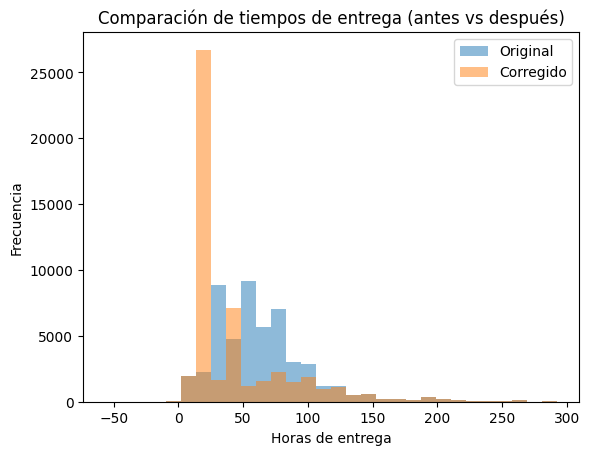

In [50]:
# Convert dates
df["Fecha recibo LD"] = pd.to_datetime(df["Fecha recibo LD"])
df["Fecha entrega"] = pd.to_datetime(df["Fecha entrega"])
df["Fecha entrega corregida"] = pd.to_datetime(df["Fecha entrega corregida"])

# Create corrected column
def corregir(row):
    estado = str(row["Estado"]).upper()
    ciudad = str(row["Ciudad"]).upper()
    if estado == "A TIEMPO":
        if "CALI" in ciudad:
            return row["Fecha recibo LD"] + pd.Timedelta(hours=24)
        else:
            return row["Fecha recibo LD"] + pd.Timedelta(hours=48)
    return row["Fecha reparto"]

df["Fecha reparto corregida"] = df.apply(corregir, axis=1)

# Differences
df["Horas_original"] = (df["Fecha entrega"] - df["Fecha recibo LD"]).dt.total_seconds() / 3600
df["Horas_corregidas"] = (df["Fecha entrega corregida"] - df["Fecha recibo LD"]).dt.total_seconds() / 3600

# Plot
plt.figure()
plt.hist(df["Horas_original"].dropna(), bins=30, alpha=0.5, label="Original")
plt.hist(df["Horas_corregidas"].dropna(), bins=30, alpha=0.5, label="Corregido")
plt.xlabel("Horas de entrega")
plt.ylabel("Frecuencia")
plt.title("Comparación de tiempos de entrega (antes vs después)")
plt.legend()

plt.show()

In [51]:
df.info()

<class 'pandas.DataFrame'>
Index: 50707 entries, 1 to 55274
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Campaña                  50707 non-null  int64         
 1   Pedido                   50707 non-null  int64         
 2   Zona                     50707 non-null  str           
 3   Dirección entrega        50707 non-null  str           
 4   Telefono                 50707 non-null  str           
 5   Barrio                   50707 non-null  str           
 6   Ciudad                   50707 non-null  str           
 7   Dias entregado           50707 non-null  int64         
 8   Fecha recibo LD          50707 non-null  datetime64[us]
 9   Fecha reparto            50707 non-null  datetime64[us]
 10  Fecha entrega            50707 non-null  datetime64[us]
 11  Transportador            50707 non-null  object        
 12  Estado                   50707 non-null  object 

In [52]:
df.to_csv("csv/cleaned_data.csv", index=False)